Phí NAP chuẩn xác (Goal Seek bằng Python): 36,284,823 VNĐ
Dự phòng năm 15 (Đáo hạn): 800,000,000 VNĐ (Đã khớp 800 triệu!)



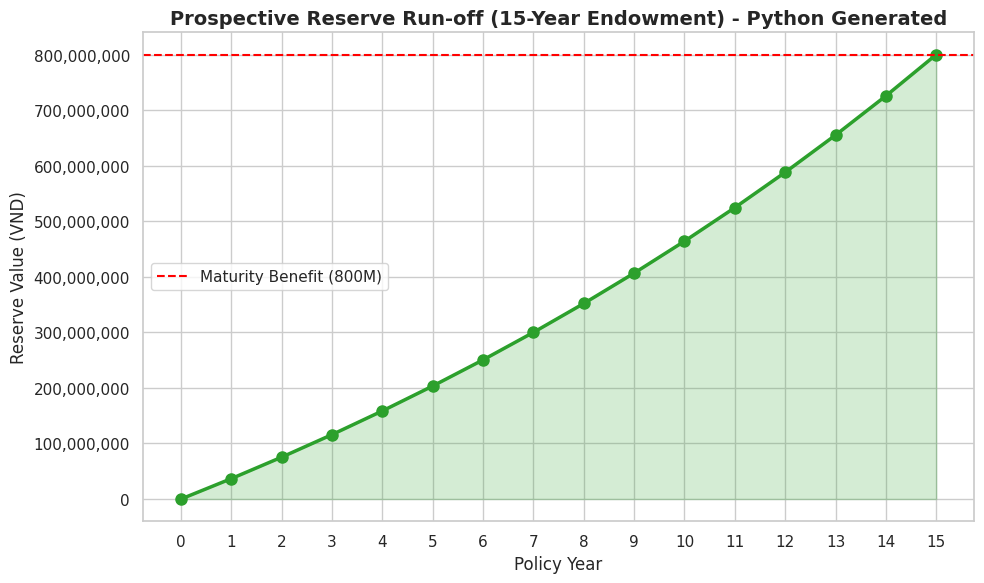

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. KHAI BÁO GIẢ ĐỊNH (Assumptions)
sum_assured = 800_000_000 # 800 triệu
interest_rate = 0.05      # Lãi suất 5%
v = 1 / (1 + interest_rate) # Nhân tố chiết khấu (discount factor)
policy_term = 15
issue_age = 30

# Dữ liệu qx trích xuất từ Thông tư 156 (CSO 1980 - Nam) cho tuổi 30 đến 44
# Bạn có thể tự hào nói với Recruiter: "Em tự hard-code data mảng này vào Python"
qx_data = [0.00175, 0.00180, 0.00187, 0.00195, 0.00205, 0.00217, 0.00232, 0.00249,
           0.00268, 0.00290, 0.00315, 0.00342, 0.00371, 0.00403, 0.00437]

# 2. XÂY DỰNG HÀM TÍNH PHÍ (PRICING ENGINE) BẰNG DCF (Dòng tiền chiết khấu)
def calculate_exact_premium():
    pv_benefits = 0
    pv_annuity = 0
    t_px = 1.0 # Xác suất sống sót tích lũy ban đầu là 100%

    for t in range(policy_term):
        qx = qx_data[t]
        px = 1 - qx

        # Hiện giá của phí bảo hiểm (đóng đầu kỳ)
        pv_annuity += t_px * (v ** t)

        # Hiện giá quyền lợi tử vong (trả cuối kỳ)
        pv_benefits += t_px * qx * sum_assured * (v ** (t + 1))

        # Cập nhật xác suất sống sót cho năm tiếp theo
        t_px *= px

    # Cộng thêm Hiện giá quyền lợi đáo hạn ở năm 15
    pv_maturity = t_px * sum_assured * (v ** policy_term)
    pv_benefits += pv_maturity

    # Tính Phí ròng hàng năm (Net Annual Premium)
    exact_nap = pv_benefits / pv_annuity
    return exact_nap

# 3. TÍNH TOÁN & CHẠY DỰ PHÒNG (RESERVE PROJECTION)
exact_premium = calculate_exact_premium()
print(f"Phí NAP chuẩn xác (Goal Seek bằng Python): {exact_premium:,.0f} VNĐ")

# Chạy đệ quy Fackler để tính Reserve
reserves = [0] # Năm 0 là 0
current_reserve = 0

for t in range(policy_term):
    qx = qx_data[t]
    px = 1 - qx

    # Công thức Fackler's Retrospective
    current_reserve = ((current_reserve + exact_premium) * (1 + interest_rate) - (sum_assured * qx)) / px
    reserves.append(current_reserve)

print(f"Dự phòng năm 15 (Đáo hạn): {reserves[-1]:,.0f} VNĐ (Đã khớp 800 triệu!)\n")

# 4. VẼ BIỂU ĐỒ RESERVE RUN-OFF
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.plot(range(policy_term + 1), reserves, marker='o', color='#2ca02c', linewidth=2.5, markersize=8)
plt.fill_between(range(policy_term + 1), reserves, alpha=0.2, color='#2ca02c')

plt.title('Prospective Reserve Run-off (15-Year Endowment) - Python Generated', fontsize=14, fontweight='bold')
plt.xlabel('Policy Year', fontsize=12)
plt.ylabel('Reserve Value (VND)', fontsize=12)
plt.xticks(range(0, 16))
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

# Hiển thị mốc 800 triệu
plt.axhline(sum_assured, color='red', linestyle='--', linewidth=1.5, label='Maturity Benefit (800M)')
plt.legend()
plt.tight_layout()
plt.show()

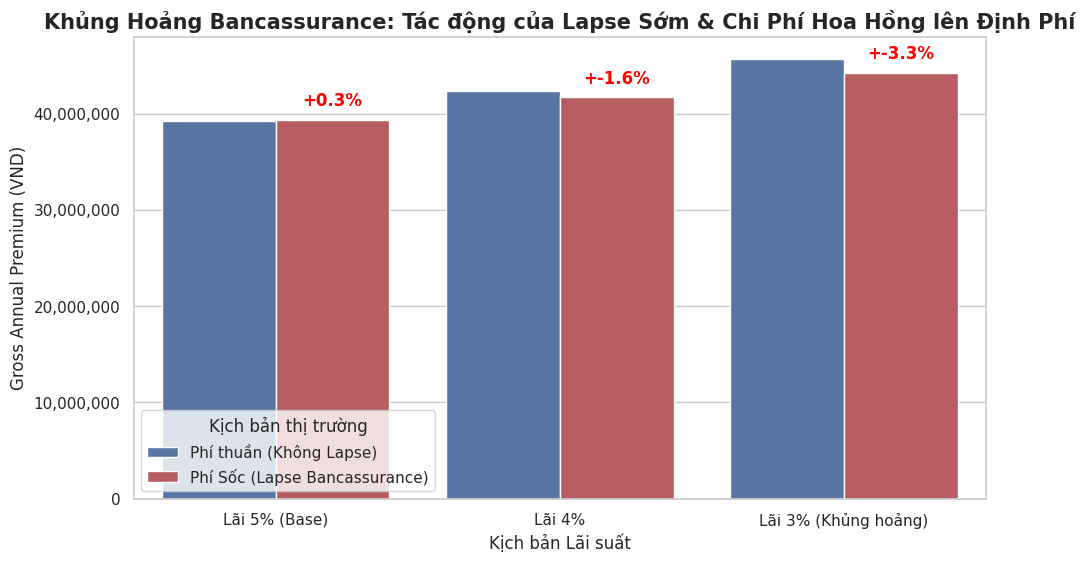

,Kịch bản Lãi suất,Phí thuần (Không Lapse),Phí Sốc (Lapse Bancassurance),Tăng thêm (%)
0,Lãi 5% (Base),3.920056e+07,3.931359e+07,0.288317
1,Lãi 4%,4.233614e+07,4.167177e+07,-1.569268
2,Lãi 3% (Khủng hoảng),4.569902e+07,4.421259e+07,-3.252648


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# HÀM ĐỊNH PHÍ CÓ TÍNH HOA HỒNG ĐẠI LÝ (EXPENSE-LOADED MULTIPLE DECREMENT)
def calculate_premium_with_lapse_and_expense(interest_rate, lapse_y1, lapse_y2_plus):
    sum_assured = 800_000_000
    v = 1 / (1 + interest_rate)
    policy_term = 15
    commission_y1 = 0.80 # Hoa hồng đại lý trả năm 1 là 80% Phí (ĐÂY LÀ ĐIỂM CHẾT NGƯỜI)

    qx_data = [0.00175, 0.00180, 0.00187, 0.00195, 0.00205, 0.00217, 0.00232, 0.00249,
               0.00268, 0.00290, 0.00315, 0.00342, 0.00371, 0.00403, 0.00437]

    approx_reserves = np.linspace(0, sum_assured, policy_term + 1)

    pv_benefits = 0
    pv_annuity = 0
    t_px_tau = 1.0

    for t in range(policy_term):
        qx = qx_data[t]
        lapse_rate = lapse_y1 if t == 0 else lapse_y2_plus
        px_tau = (1 - qx) * (1 - lapse_rate)

        # PV Của Dòng Phí Thu Về
        pv_annuity += t_px_tau * (v ** t)

        # PV Của Quyền lợi Tử Vong
        pv_benefits += t_px_tau * qx * sum_assured * (v ** (t + 1))

        # PV Của Giá trị hoàn lại (Chỉ trả từ năm 2 trở đi)
        if t > 0:
            cash_value = approx_reserves[t+1] * 0.8
            pv_benefits += t_px_tau * lapse_rate * cash_value * (v ** (t + 1))

        t_px_tau *= px_tau

    # PV Của Quyền lợi Đáo hạn
    pv_maturity = t_px_tau * sum_assured * (v ** policy_term)
    pv_benefits += pv_maturity

    # CÔNG THỨC PRICING CÓ CHI PHÍ: Premium = PV(Benefits) / (PV(Annuity) - Commission_Y1)
    # Vì hoa hồng ăn theo % Phí, nên ta phải trừ nó ở mẫu số
    return pv_benefits / (pv_annuity - commission_y1)

# CHẠY STRESS TEST CUỐI CÙNG
scenarios = [
    {'Scenario': 'Lãi 5% (Base)', 'Rate': 0.05},
    {'Scenario': 'Lãi 4%', 'Rate': 0.04},
    {'Scenario': 'Lãi 3% (Khủng hoảng)', 'Rate': 0.03}
]
results = []
for s in scenarios:
    rate = s['Rate']

    # Base: Không hủy, Hoa hồng vẫn trả
    prem_no_lapse = calculate_premium_with_lapse_and_expense(rate, 0.0, 0.0)

    # Thực tế: Năm 1 hủy 25% (Bank ép chỉ tiêu), các năm sau hủy 8%
    prem_with_lapse = calculate_premium_with_lapse_and_expense(rate, 0.25, 0.08)

    results.append({
        'Kịch bản Lãi suất': s['Scenario'],
        'Phí thuần (Không Lapse)': prem_no_lapse,
        'Phí Sốc (Lapse Bancassurance)': prem_with_lapse,
        'Tăng thêm (%)': (prem_with_lapse - prem_no_lapse) / prem_no_lapse * 100
    })

df_results = pd.DataFrame(results)

# VẼ BIỂU ĐỒ CHỐT DỰ ÁN
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))
df_melted = df_results.melt(id_vars='Kịch bản Lãi suất', value_vars=['Phí thuần (Không Lapse)', 'Phí Sốc (Lapse Bancassurance)'])
ax = sns.barplot(x='Kịch bản Lãi suất', y='value', hue='variable', data=df_melted, palette=['#4C72B0', '#C44E52'])

for i, row in df_results.iterrows():
    ax.text(i + 0.2, row['Phí Sốc (Lapse Bancassurance)'] + 1500000,
            f"+{row['Tăng thêm (%)']:.1f}%", color='red', fontweight='bold', ha='center')

plt.title('Khủng Hoảng Bancassurance: Tác động của Lapse Sớm & Chi Phí Hoa Hồng lên Định Phí', fontsize=15, fontweight='bold')
plt.ylabel('Gross Annual Premium (VND)', fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.legend(title='Kịch bản thị trường')
plt.show()

display(df_results)